# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 1: Land Eligibility for Wind Turbines (28 points)

Perform an eligibility analysis for the land area available for the development of wind parks in the
Grand Duchy of Luxembourg considering the following criteria:

1. Exclude natural protection areas of the [Natura 2000](https://ec.europa.eu/environment/nature/natura2000/index_en.htm) dataset (`url_natura2000`).
2. Exclude areas within 10 km of airports from the [Natural Earth](https://www.naturalearthdata.com/) dataset (`url_airports`).
3. Exclude areas within 600 m of major roads from the [Natural Earth](https://www.naturalearthdata.com/) dataset (`url_roads`).
4. Exclude the following land cover types from the [CORINE Land Cover](https://land.copernicus.eu/pan-european/corine-land-cover) dataset (`url_corine`, EPSG:3035), including an 800 meter buffer around them:
   - Continuous urban fabric
   - Discontinuous urban fabric
   - Industrial or commercial units
   - Port areas
   - Mineral extraction sites
   - Dump sites
   - Construction sites
   - Green urban areas
   - Sport and leisure facilities
5. Include **only** the following land cover types from the [CORINE Land Cover](https://land.copernicus.eu/pan-european/corine-land-cover) dataset (`url_corine`, EPSG:3035):
   - Non-irrigated arable land
   - Permanently irrigated land
   - Pastures
   - Annual crops associated with permanent crops
   - Land principally occupied by agriculture with significant areas of natural vegetation
   - Natural grasslands
   - Sparsely vegetated areas

*Refer to the course materials to recall how the land cover types are encoded in the CORINE dataset.*

In [19]:
url_natura2000 = "https://tubcloud.tu-berlin.de/s/zPMqJFPD8tKq2Ss/download/Natura2000_end2021-LU.gpkg"
url_airports = (
    "https://tubcloud.tu-berlin.de/s/TbEJ9Lsy9EpTcQS/download/ne_10m_airports.gpkg"
)
url_roads = "https://tubcloud.tu-berlin.de/s/zcKQ95TgpyMJb8E/download/ne_10m_roads.gpkg"
url_corine = "https://tubcloud.tu-berlin.de/s/z7aY8HNCdETQMT7/download/U2018_CLC2018_V2020_20u1-LU.tif"
url_countries = (
    "https://tubcloud.tu-berlin.de/s/7bpHrAkjMT3ADSr/download/country_shapes.geojson"
)

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show

**a)** Load the country shapes as `geopandas.GeoDataFrame`, reduce it to a single entry for Luxembourg and the `geometry` column, and reproject it to the coordinate reference system EPSG:3035. Return the resulting `geopandas.GeoSeries`. **(2 points)**

In [21]:
# YOUR CODE HERE
gdf = gpd.read_file(url_countries)
gdf_lu = gdf[gdf["name"] == "LU"]
gdf_lu = gdf_lu.to_crs(3035)
gdf_lu = gdf_lu["geometry"]
gdf_lu

91    POLYGON ((4043458.177 3008253.833, 4042879.385...
Name: geometry, dtype: geometry

In [22]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, gpd.GeoSeries)

In [23]:
### AUTOGRADING CELL - DO NOT TOUCH!


**b)** Calculate the share (in percent) of the area of Luxembourg that is _excluded_ by each of the exclusion criteria 1.–5. individually, using `atlite` functionality. Return the value as a float. **(7 points)**

1. Natura 2000 areas

In [ ]:
# YOUR CODE HERE
gdf_lu = gdf.loc[gdf["name"] == "LU"].to_crs(3035).geometry
excluder = ExclusionContainer(crs=3035)
excluder.add_geometry(url_natura2000)
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_exclude_area = float(100 - (eligible_area / country_area * 100))
total_exclude_area




np.float64(24.187323996691234)

In [36]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [37]:
### AUTOGRADING CELL - DO NOT TOUCH!

2. Airports

In [ ]:
# YOUR CODE HERE
excluder = ExclusionContainer(crs=3035)
excluder.add_geometry(url_airports, buffer=10_000)  # 10 km ✓
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_exclude_area = float(100 - (eligible_area / country_area * 100))
total_exclude_area

12.02846666251034

In [43]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [44]:
### AUTOGRADING CELL - DO NOT TOUCH!

3. Major roads

In [ ]:
# YOUR CODE HERE
excluder = ExclusionContainer(crs=3035) 
excluder.add_geometry(url_roads, buffer = 600)
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_exclude_area = float(100 - (eligible_area / country_area * 100))
total_exclude_area


10.569756479745863

In [ ]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [ ]:
### AUTOGRADING CELL - DO NOT TOUCH!

4. CORINE land classes (exclusion)

In [62]:
# YOUR CODE HERE
excluder = ExclusionContainer(crs=3035) 
codes_excl = [1, 2, 3, 5, 7, 8, 9, 10, 11]
excluder.add_raster(url_corine, codes=codes_excl, crs=3035, buffer = 800, nodata=0)
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_exclude_area = float(100 - (eligible_area / country_area * 100))
total_exclude_area


53.86488809086909

In [63]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [55]:
### AUTOGRADING CELL - DO NOT TOUCH!

5. CORINE land classes (inclusion)

In [57]:
# YOUR CODE HERE

excluder = ExclusionContainer(crs=3035) 
codes_incl = [12,13,18,19,21,26,32]
excluder.add_raster(url_corine, codes=codes_incl, crs=3035, nodata=0, invert= True)
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_exclude_area = float(100- (eligible_area / country_area * 100))
total_exclude_area

60.8659302347968

In [58]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)


In [59]:
### AUTOGRADING CELL - DO NOT TOUCH!

**c)** Calculate the share (in percent) of the area of Luxembourg that is _eligible_ for wind park development when considering all criteria at once, using `atlite` functionality. Return the value as a float. **(3 points)**

In [64]:
# YOUR CODE HERE
gdf_lu = gdf.loc[gdf["name"] == "LU"].to_crs(3035).geometry
excluder = ExclusionContainer(crs=3035)
excluder.add_geometry(url_natura2000)
excluder.add_geometry(url_airports, buffer=10_000)
excluder.add_geometry(url_roads, buffer=600)
codes_excl = [1, 2, 3, 5, 7, 8, 9, 10, 11]
codes_incl = [12,13,18,19,21,26,32]
excluder.add_raster(url_corine, codes=codes_excl, crs=3035, buffer = 800,nodata=0)
excluder.add_raster(url_corine, codes=codes_incl, crs=3035, nodata=0, invert= True)
band, transform = shape_availability(gdf_lu, excluder)
eligible_area = float(band.sum()) * float(excluder.res**2)
country_area = float(gdf_lu.area.sum())
total_include_area = float((eligible_area / country_area * 100))
total_include_area


11.913886031477467

In [65]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [66]:
### AUTOGRADING CELL - DO NOT TOUCH!

**d)** What is the total eligible area for wind park development in Luxembourg in km²? Return the value as a float. **(2 points)**

In [68]:
# YOUR CODE HERE
eligible_area/1000000

310.77

In [69]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**e)** Visualize the eligible areas on a map of Luxembourg at 100m resolution, using `atlite` functionality. **(3 points)**

(np.float64(4013100.0),
 np.float64(4069300.0),
 np.float64(2933400.0),
 np.float64(3014800.0))

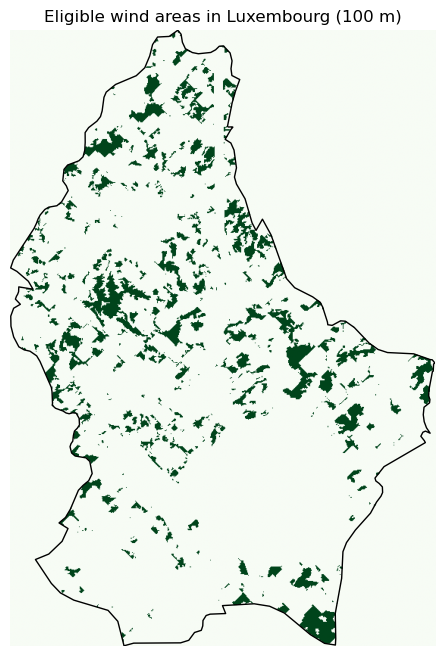

In [85]:
# YOUR CODE HERE
excluder = ExclusionContainer(crs=3035, res=100)
excluder.add_geometry(url_natura2000)
excluder.add_geometry(url_airports, buffer=10_000)
excluder.add_geometry(url_roads, buffer=600)
excluder.add_raster(url_corine, codes=[1, 2, 3, 5, 7, 8, 9, 10, 11], buffer=800, crs=3035, nodata=0)
excluder.add_raster(url_corine, codes=[12, 13, 18, 19, 21, 26, 32], crs=3035, invert=True, nodata=0)
fig, ax = plt.subplots(figsize=(6, 8))
excluder.plot_shape_availability(gdf_lu, ax=ax)  # atlite's own plot
ax.set_title("Eligible wind areas in Luxembourg (100 m)")
ax.axis("off")

**f)** Assume that for the expansion of wind power in Luxembourg, a capacity density of 4 MW/km² of eligible land can be achieved and that the wind conditions result in an average capacity factor of 32%. What is the total electricity (in TWh) that could be produced from wind power in Luxembourg each year? Return the value as a float. **(4 points)**

In [78]:
# YOUR CODE HERE
electricity = ((eligible_area/1000000) * 4 * 0.32 * 8760)/1000000
electricity

3.484601856

In [79]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**g)** Perform a sensitivity analysis on the distance criterion to CORINE land classes by repeating the land eligibility calculation with distance requirements of 0m, 300m, 600m, 900m, _together with all other criteria_. Return the results as a `pandas.Series` so that the index contains the distance values (in meters) and the values contain the corresponding share of eligible area (in percent). **(7 points)**

In [89]:
# YOUR CODE HERE
distances = [0, 300, 600, 900]
codes_excl = [1, 2, 3, 5, 7, 8, 9, 10, 11]
codes_incl = [12, 13, 18, 19, 21, 26, 32]
country_area = float(gdf_lu.area.sum())

results = {}
for d in distances:
    excluder = ExclusionContainer(crs=3035, res=100)
    excluder.add_geometry(url_natura2000)
    excluder.add_geometry(url_airports, buffer=10_000)
    excluder.add_geometry(url_roads, buffer=600)
    excluder.add_raster(url_corine, codes=codes_excl, buffer=d, crs=3035, nodata=0)
    excluder.add_raster(url_corine, codes=codes_incl, crs=3035, invert=True, nodata=0)

    band, transform = shape_availability(gdf_lu, excluder)
    eligible_share = float(band.sum() * excluder.res**2 / country_area * 100)
    results[d] = eligible_share

pd.Series(results)

0      26.111104
300    19.007320
600    14.487043
900    10.757652
dtype: float64

In [90]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [91]:
### AUTOGRADING CELL - DO NOT TOUCH!